# Slow Dynamics and High Variability in Networks with Clustered Connections




In [1]:
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

from model import ClusterParams, ModelParams, NeuronNetwork, firing_rate

# Run and plot an un-clustered network

In [2]:
params = ModelParams()
cluster_params = ClusterParams(enabled=False, R_ee=1.0)

unclustered_network = NeuronNetwork(params, cluster_params)
unclustered_network.run()

WARNING    Removing unsupported flag '-w' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Removing unsupported flag '-O3' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Removing unsupported flag '-ffast-math' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Removing unsupported flag '-fno-finite-math-only' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Removing unsupported flag '-std=c++11' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Cannot use Cython, a test compilation failed: command 'x86_64-linux-gnu-g++' failed: No such file or directory (CompileError)
Certain compiler configurations (e.g. clang in a conda environment on OS X) are known to be problematic. Note that you can switch the compiler by setting the 'CC' and 'CXX' environment variables. For example, you may want to try 'CC=gcc' and 'CXX=g++'. [brian2.codegen.runtim

In [3]:
def plot_spike_raster(spike_monitor_e, spike_monitor_i=None, n_e=0, title="Spike raster", ax=None):
    """Plot a spike raster for excitatory (and optionally inhibitory) neurons.
    
    Args:
        spike_monitor_e: Brian2 SpikeMonitor for excitatory neurons
        spike_monitor_i: Brian2 SpikeMonitor for inhibitory neurons (optional)
        n_e: Number of excitatory neurons (used to offset inhibitory neuron indices)
        title: Plot title
        ax: Matplotlib axes to plot on. If None, creates a new figure.
    
    Returns:
        The axes object
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 7))
    
    ax.plot(spike_monitor_e.t / ms, spike_monitor_e.i, ".", markersize=2, label="E")
    if spike_monitor_i is not None:
        ax.plot(
            spike_monitor_i.t / ms,
            spike_monitor_i.i + n_e,
            ".",
            markersize=2,
            label="I",
        )
    ax.set_ylabel("Neuron index")
    ax.set_title(title)
    ax.legend(loc="upper right")
    
    return ax


def plot_trial_rasters(network, n_trials=9, ncols=3, figsize=None, show_inhibitory=False):
    """Plot spike rasters for multiple trials of a network in a grid"""
    nrows = int(np.ceil(n_trials / ncols))
    
    if figsize is None:
        figsize = (4 * ncols, 3 * nrows)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes = np.atleast_2d(axes)  # Ensure 2D array even if nrows=1
    
    for trial in range(n_trials):
        row = trial // ncols
        col = trial % ncols
        ax = axes[row, col]
        
        network.run()
        
        spike_monitor_i = network.spike_monitor_i if show_inhibitory else None
        n_e = network.params.N_E if show_inhibitory else 0
        
        plot_spike_raster(
            network.spike_monitor_e,
            spike_monitor_i,
            n_e=n_e,
            title=f"Trial {trial + 1}",
            ax=ax
        )
        
        # Only show legend on first plot to reduce clutter
        if trial > 0:
            ax.get_legend().remove()
    
    # Hide any unused subplots
    for idx in range(n_trials, nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    return fig, axes

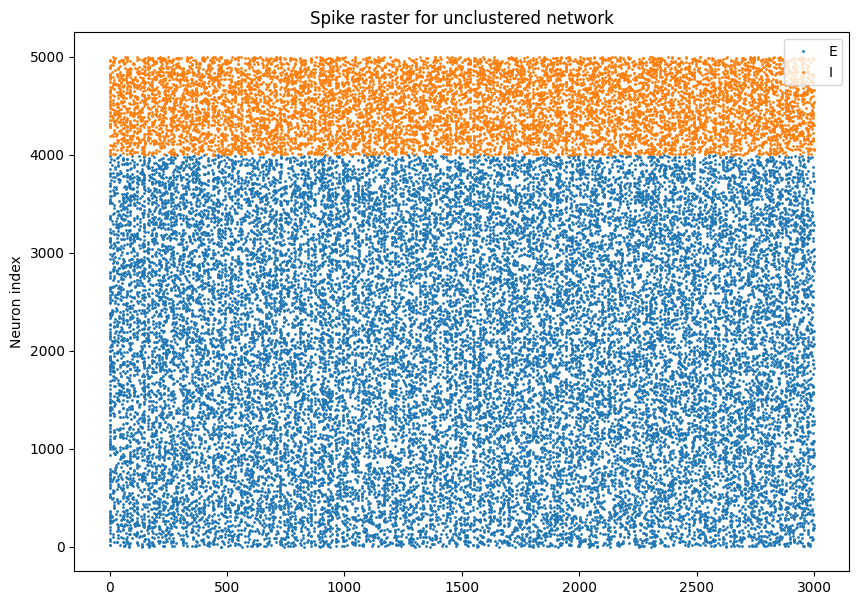

In [4]:
# Single raster plot
plot_spike_raster(
    unclustered_network.spike_monitor_e,
    unclustered_network.spike_monitor_i,
    n_e=params.N_E,
    title="Spike raster for unclustered network",
)
plt.show()

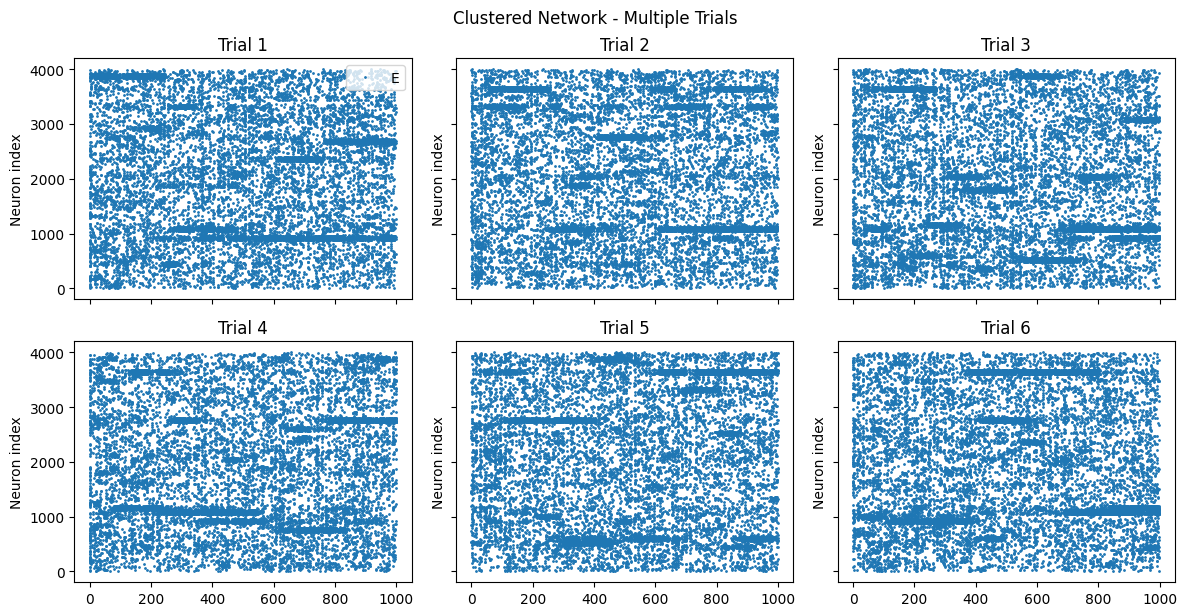

In [5]:
# Plot multiple trials in a grid
# Create a fresh network for the trial rasters
trial_network = NeuronNetwork(
    ModelParams(duration=1*second),  # Shorter duration for quick visualization
    ClusterParams(enabled=True, R_ee=2.3),
    seed=123
)

fig, axes = plot_trial_rasters(trial_network, n_trials=6, ncols=3, show_inhibitory=False)
fig.suptitle("Clustered Network - Multiple Trials", y=1.02)
plt.show()

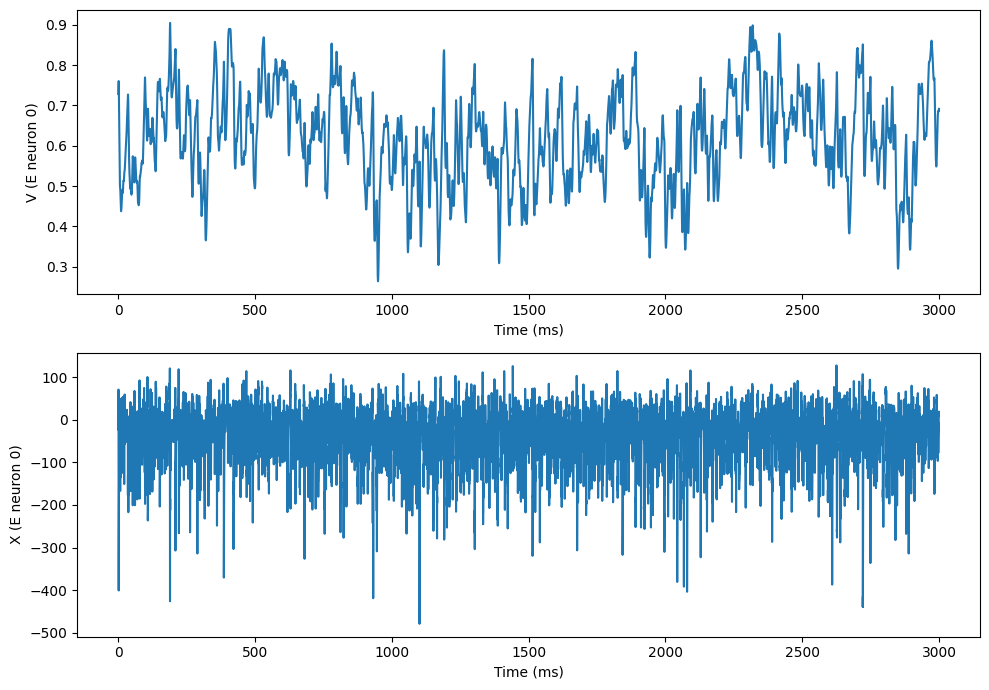

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')

axes[1].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()

# Run and plot a clustered network

In [7]:
params = ModelParams()
cluster_params = ClusterParams(enabled=True, R_ee=2.3)

clustered_network = NeuronNetwork(params, cluster_params)
clustered_network.run()

<Axes: title={'center': 'Spike raster'}, ylabel='Neuron index'>

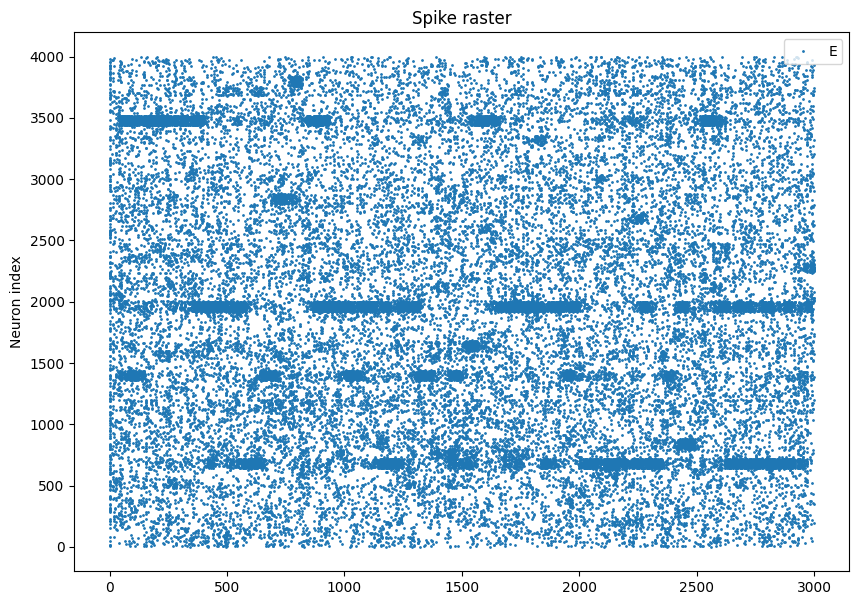

In [8]:
plot_spike_raster(clustered_network.spike_monitor_e)

## Plot the membrane potentials of a few neurons

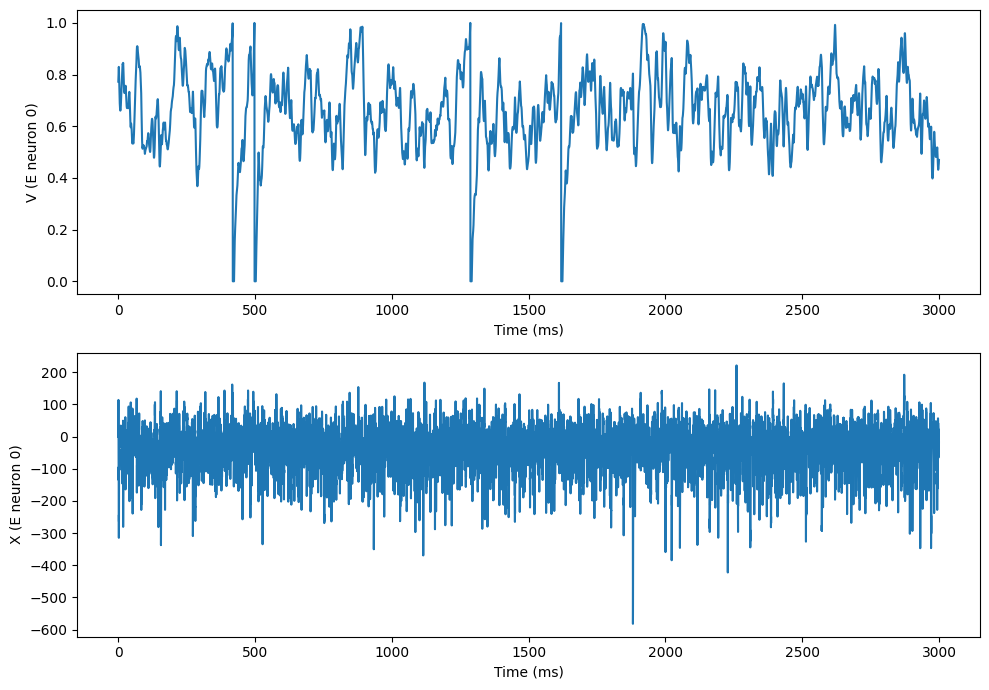

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')

axes[1].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()
plt.show()

# Plotting the firing rate distribution

(4000,) (1000,)
(5000,)
(4000,) (1000,)
(5000,)


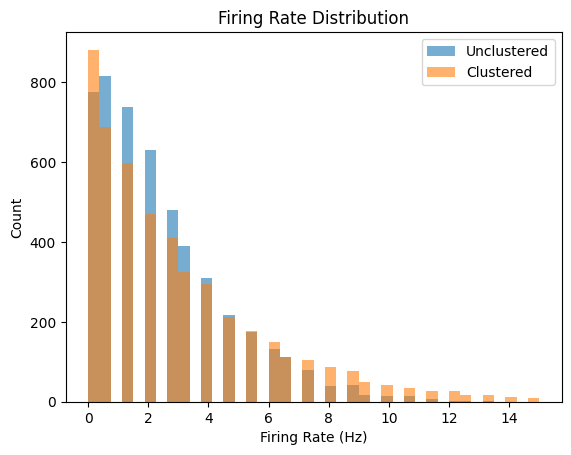

In [10]:
def plot_firing_rate_distribution(networks, labels, title, params):
    fig, ax = plt.subplots()

    firing_rates_by_label = {}
    for network, label in zip(networks, labels):
        firing_rates_e = firing_rate(
            network.spike_monitor_e,
            params.N_E,
            params.analysis_start_t,
            params.analysis_window_t,
        )
        firing_rates_i = firing_rate(
            network.spike_monitor_i,
            params.N_I,
            params.analysis_start_t,
            params.analysis_window_t,
        )
        print(firing_rates_e.shape, firing_rates_i.shape)

        rates = np.concatenate([firing_rates_e, firing_rates_i])
        print(rates.shape)

        firing_rates_by_label[label] = rates
        ax.hist(
            rates,
            bins=40,
            range=(0, 15),
            alpha=0.6,
            label=label,
        )

    ax.set_xlabel('Firing Rate (Hz)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()

    return firing_rates_by_label

firing_rates_by_label = plot_firing_rate_distribution(
    [unclustered_network, clustered_network],
    ["Unclustered", "Clustered"],
    title="Firing Rate Distribution",
    params=params,
)

# Checking difference of exponential filter to an ODE

In [51]:
# TODO
# def x_prime(x, t1):
#     return -x / t1

# def g_prime(g, x, t2):
#     return (x - g) / t2

# def filter(t, t1, t2):
#     return 1 / (t2 - t1) * (np.exp(-t / t2) - np.exp(-t / t1))

# def euler_solve(x0, t, t1):
#     """Simple Euler method for x' = -x/t1."""
#     x = np.zeros_like(t)
#     x[0] = x0
#     dt = t[1] - t[0]
#     for i in range(1, len(t)):
#         x[i] = x[i - 1] + dt * x_prime(x[i - 1], t1)
#     return x

# t1 = 5.0
# x0 = 1.0
# t = np.linspace(0.0, 30.0, 600)

# x_num = euler_solve(x0, t, t1)

# sol = solve_ivp(
#     lambda tau, y: x_prime(y, t1),
#     t_span=(t[0], t[-1]),
#     y0=[x0],
#     t_eval=t,
# )
# x_scipy = sol.y[0]

# x_exact = x0 * np.exp(-t / t1)

# fig, ax = plt.subplots()
# ax.plot(t, x_num, label="Euler (numerical)")
# ax.plot(t, x_scipy, label="SciPy solve_ivp")
# ax.plot(t, x_exact, "--", label="Exact")
# ax.set_xlabel("t")
# ax.set_ylabel("x")
# ax.legend()
# plt.show()

# # Plot the filter for a sample t2.
# t2 = 2.0

# fig, ax = plt.subplots()
# ax.plot(t, filter(t, t1, t2), label="filter(t)")
# ax.set_xlabel("t")
# ax.set_ylabel("filter")
# ax.legend()
# plt.show()


    

# Experiment

Now instead of looking at a single network, we follow the paper's protocol of testing the uniform and clustered networks across 12 different network realizations, with 9 trials for each realization. This enables statistical analysis on spike counts.

## Metrics

**Firing Rate**: Spikes per neuron divided by the analysis window duration (Hz).

**Fano Factor**: Variance-to-mean ratio of spike counts across trials. A Poisson process has FF=1; values >1 indicate higher variability (bursty firing).

**Correlation Coefficient**: Spikes are binned into sliding time windows to create a spike count time series per neuron. We overlap the sliding time windows. The correlation coefficient between neuron pairs is: $\rho_{ij} = \text{Cov}(X_i, X_j) / (\sigma_i \sigma_j)$.

In [ ]:
class Experiment:
    def __init__(
        self,
        realizations=12,
        trials=9,
        model_params=ModelParams(),
        cluster_params=ClusterParams(enabled=True, R_ee=2.5),
        seed=42,
        corr_window=50*ms,
        corr_step=25*ms
    ):
        self.realizations = realizations
        self.trials = trials
        self.model_params = model_params
        self.cluster_params = cluster_params
        self.seed = seed
        
        # Correlation analysis parameters
        self.corr_window = corr_window
        self.corr_step = corr_step
        
        # Initialize networks
        self.uniform_networks = self._initialize_networks(
            realizations, model_params, ClusterParams(enabled=False, R_ee=1.0), "uniform"
        )
        self.clustered_networks = self._initialize_networks(
            realizations, model_params, cluster_params, "clustered"
        )
        
        # Fano factor spike counts: (realizations, trials, N_E)
        counts_shape = (realizations, trials, model_params.N_E)
        self.uniform_spike_counts = np.zeros(counts_shape, dtype=np.int32)
        self.clustered_spike_counts = np.zeros(counts_shape, dtype=np.int32)
        
        # Firing rates: (realizations, trials, N_E)
        rates_shape = (realizations, trials, model_params.N_E)
        self.uniform_firing_rates = np.zeros(rates_shape, dtype=np.float64)
        self.clustered_firing_rates = np.zeros(rates_shape, dtype=np.float64)
        
        # Correlation accumulators: accumulate covariance/variance across all trials
        # We compute running sums and divide at the end to get means
        n_e = model_params.N_E
        self.uniform_cov_sum = np.zeros((n_e, n_e), dtype=np.float64)
        self.uniform_var_sum = np.zeros(n_e, dtype=np.float64)
        self.clustered_cov_sum = np.zeros((n_e, n_e), dtype=np.float64)
        self.clustered_var_sum = np.zeros(n_e, dtype=np.float64)

    def _initialize_networks(self, realizations, model_params, cluster_params, name):
        networks = []
        for r in range(realizations):
            network = NeuronNetwork(model_params, cluster_params, seed=self.seed + 1000 * r)
            print(f"Built {name} network {r + 1}/{realizations}")
            networks.append(network)
        return networks

    def _count_spikes_in_window(self, spike_times, spike_ids, n_neurons, start_t, end_t):
        """Count spikes per neuron in a time window."""
        mask = (spike_times >= start_t) & (spike_times < end_t)
        return np.bincount(spike_ids[mask], minlength=n_neurons)

    def run(self):
        print("Running uniform networks...")
        self._run_networks(
            self.uniform_networks, 
            self.uniform_spike_counts,
            self.uniform_firing_rates,
            self.uniform_cov_sum,
            self.uniform_var_sum
        )
        print("Running clustered networks...")
        self._run_networks(
            self.clustered_networks, 
            self.clustered_spike_counts,
            self.clustered_firing_rates,
            self.clustered_cov_sum,
            self.clustered_var_sum
        )
        print("Done.")

    def _run_networks(self, networks, spike_counts, firing_rates_arr, cov_sum, var_sum):
        params = self.model_params
        start_t = params.analysis_start_t
        
        # Different windows for different analyses
        fano_end_t = start_t + params.fano_factor_window_t
        firing_rate_end_t = start_t + params.firing_rate_window_t
        corr_end_t = start_t + params.analysis_window_t
        corr_timerange = (start_t, corr_end_t)

        for r, network in enumerate(networks):
            for t in range(self.trials):
                network.run()
                
                spike_times_e = network.spike_monitor_e.t
                spike_ids_e = network.spike_monitor_e.i
                
                # Fano factor: count spikes in the fano_factor_window
                spike_counts[r, t, :] = self._count_spikes_in_window(
                    spike_times_e, spike_ids_e, params.N_E, start_t, fano_end_t
                )
                
                # Firing rates: count spikes and convert to Hz
                counts_e = self._count_spikes_in_window(
                    spike_times_e, spike_ids_e, params.N_E, start_t, firing_rate_end_t
                )
                firing_rate_duration = float(params.firing_rate_window_t)
                firing_rates_arr[r, t, :] = counts_e / firing_rate_duration
                
                # Correlation: compute window counts and accumulate cov/var
                window_counts = window_spikes_all_neurons(
                    spike_times_e, spike_ids_e, params.N_E,
                    self.corr_window, self.corr_step, corr_timerange
                )
                cov_matrix = np.cov(window_counts, rowvar=True, bias=False)
                row_vars = np.var(window_counts, axis=1, ddof=1)
                
                cov_sum += cov_matrix
                var_sum += row_vars
                
                print(f"  Realization {r + 1}/{len(networks)}, Trial {t + 1}/{self.trials}")

    def _compute_fano_factor(self, spike_counts):
        mean = spike_counts.mean(axis=1)
        var = spike_counts.var(axis=1, ddof=1)
        with np.errstate(divide="ignore", invalid="ignore"):
            return np.where(mean > 0, var / mean, np.nan)

    def fano_factor(self):
        return (
            self._compute_fano_factor(self.uniform_spike_counts),
            self._compute_fano_factor(self.clustered_spike_counts),
        )

    def get_firing_rates(self):
        """Get excitatory firing rates across all trials.
        
        Returns:
            (uniform_rates, clustered_rates): Flattened arrays of firing rates
        """
        return self.uniform_firing_rates.ravel(), self.clustered_firing_rates.ravel()

    def mean_cov_var(self):
        """Get mean covariance matrices and variances from accumulated sums."""
        total_trials = self.realizations * self.trials
        return (
            self.uniform_cov_sum / total_trials,
            self.uniform_var_sum / total_trials,
            self.clustered_cov_sum / total_trials,
            self.clustered_var_sum / total_trials,
        )

    def correlation_coefficients(self, same_cluster_only=False):
        """Compute correlation coefficients from accumulated statistics"""
        uniform_cov, uniform_var, clustered_cov, clustered_var = self.mean_cov_var()
        
        if same_cluster_only:
            uniform_coeffs = calc_cluster_coeffs(uniform_cov, uniform_var, self.model_params, self.cluster_params)
            clustered_coeffs = calc_cluster_coeffs(clustered_cov, clustered_var, self.model_params, self.cluster_params)
        else:
            uniform_coeffs = calc_coeffs(uniform_cov, uniform_var, self.model_params)
            clustered_coeffs = calc_coeffs(clustered_cov, clustered_var, self.model_params)
        
        return uniform_coeffs, clustered_coeffs


def window_spikes_all_neurons(spike_times, spike_ids, n_neurons, window, step, timerange):
    """Compute spike counts in sliding windows for all neurons at once"""
    start_time = float(timerange[0])
    end_time = float(timerange[1])
    window = float(window)
    step = float(step)
    
    window_starts = np.arange(start_time, end_time - window + step, step)
    n_windows = len(window_starts)
    
    window_counts = np.zeros((n_neurons, n_windows), dtype=np.int32)
    spike_times = np.asarray(spike_times)
    spike_ids = np.asarray(spike_ids)
    
    for w, ws in enumerate(window_starts):
        mask = (spike_times >= ws) & (spike_times <= ws + window)
        window_counts[:, w] = np.bincount(spike_ids[mask], minlength=n_neurons)
    
    return window_counts


def calc_coeffs(cov_matrix, neuron_vars, params):
    """Calculates the correlation coefficients for all neuron pairs."""
    coeffs = []
    for i in range(params.N_E):
        for j in range(i+1, params.N_E):
            coeffs.append(cov_matrix[i][j] / np.sqrt(neuron_vars[i] * neuron_vars[j]))
    
    return np.array(coeffs)


def calc_cluster_coeffs(cov_matrix, neuron_vars, params, cluster_params):
    """Calculates correlation coefficients for same-cluster pairs only."""
    coeffs = []
    n_cluster = cluster_params.cluster_size
    for i in range(params.N_E):
        j_same_cluster = (i // n_cluster)*n_cluster + n_cluster
        for j in range(i+1, j_same_cluster):
            coeffs.append(cov_matrix[i][j] / np.sqrt(neuron_vars[i] * neuron_vars[j]))
    
    return np.array(coeffs)



In [37]:
# Plotting functions

def plot_firing_rate_distribution(experiment, bins=20, rate_range=(0, 15)):
    uniform_rates, clustered_rates = experiment.get_firing_rates()
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.hist(uniform_rates, bins=bins, histtype='step', linewidth=2, color='black', range=rate_range,  
            label=f'Uniform (mean={np.mean(uniform_rates):.2f} Hz)')
    ax.hist(clustered_rates, bins=bins, histtype='step', linewidth=2, color='limegreen', range=rate_range,
            label=f'Clustered (mean={np.mean(clustered_rates):.2f} Hz)')
    
    ax.set_xlabel('Firing Rate (Hz)')
    ax.set_ylabel('Count')
    ax.set_title(f'Firing Rate Distribution (Excitatory Neurons)\n'
                 f'{experiment.realizations} realizations × {experiment.trials} trials')
    ax.legend()
    
    return fig, ax


def plot_fano_factor(experiment):
    uniform_ff, clustered_ff = experiment.fano_factor()
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    bins = np.linspace(0, 3, 35)
    ax.hist(uniform_ff.ravel(), bins=bins, histtype='step', linewidth=1.5, label='Uniform')
    ax.hist(clustered_ff.ravel(), bins=bins, histtype='step', linewidth=1.5, label='Clustered')
    
    uniform_mean = np.nanmean(uniform_ff)
    clustered_mean = np.nanmean(clustered_ff)
    ax.axvline(uniform_mean, color='C0', alpha=0.7, linestyle='--')
    ax.axvline(clustered_mean, color='C1', alpha=0.7, linestyle='--')
    
    ax.set_xlabel('Fano factor')
    ax.legend()
    
    print(f"Mean Fano Factor (Uniform): {uniform_mean:.3f}")
    print(f"Mean Fano Factor (Clustered): {clustered_mean:.3f}")
    
    return fig, ax


def plot_correlation_coefficients(experiment):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # All pairs
    uniform_coeffs, clustered_coeffs = experiment.correlation_coefficients(same_cluster_only=False)
    
    bins_all = np.linspace(-0.5, 0.5, 50)
    axes[0].hist(uniform_coeffs, bins=bins_all, histtype='step', linewidth=2, color='black', label='Uniform')
    axes[0].hist(clustered_coeffs, bins=bins_all, histtype='step', linewidth=2, color='limegreen', label='Clustered')
    axes[0].set_xlabel('Correlation (all pairs)')
    axes[0].set_xlim(-0.5, 0.5)
    axes[0].legend()
    
    # Scientific notation on y-axis
    fmt0 = ScalarFormatter(useMathText=True)
    fmt0.set_powerlimits((6, 6))
    axes[0].yaxis.set_major_formatter(fmt0)
    
    # Mean markers (triangles at top)
    y_top0 = axes[0].get_ylim()[1]
    axes[0].plot([np.nanmean(uniform_coeffs)], [y_top0 * 1.01], marker='v', markersize=6, color='black', clip_on=False)
    axes[0].plot([np.nanmean(clustered_coeffs)], [y_top0 * 1.01], marker='v', markersize=6, color='limegreen', clip_on=False)
    
    # Same cluster pairs only
    uniform_cluster_coeffs, clustered_cluster_coeffs = experiment.correlation_coefficients(same_cluster_only=True)
    
    bins_cluster = np.linspace(-0.5, 1.0, 50)
    axes[1].hist(uniform_cluster_coeffs, bins=bins_cluster, histtype='step', linewidth=2, color='black', label='Uniform')
    axes[1].hist(clustered_cluster_coeffs, bins=bins_cluster, histtype='step', linewidth=2, color='limegreen', label='Clustered')
    axes[1].set_xlabel('Correlation (same cluster)')
    axes[1].set_xlim(-0.5, 1.0)
    axes[1].legend()
    
    # Scientific notation on y-axis
    fmt1 = ScalarFormatter(useMathText=True)
    fmt1.set_powerlimits((4, 4))
    axes[1].yaxis.set_major_formatter(fmt1)
    
    # Mean markers (triangles at top)
    y_top1 = axes[1].get_ylim()[1]
    axes[1].plot([np.nanmean(uniform_cluster_coeffs)], [y_top1 * 1.01], marker='v', markersize=6, color='black', clip_on=False)
    axes[1].plot([np.nanmean(clustered_cluster_coeffs)], [y_top1 * 1.01], marker='v', markersize=6, color='limegreen', clip_on=False)
    
    print(f"Mean correlation (all pairs) - Uniform: {np.nanmean(uniform_coeffs):.4f}, Clustered: {np.nanmean(clustered_coeffs):.4f}")
    print(f"Mean correlation (same cluster) - Uniform: {np.nanmean(uniform_cluster_coeffs):.4f}, Clustered: {np.nanmean(clustered_cluster_coeffs):.4f}")
    
    return fig, axes

In [33]:
# Run experiment with fewer realizations/trials for testing
e = Experiment(
    realizations=2, 
    trials=5, 
    model_params=ModelParams(duration=3*second),
    cluster_params=ClusterParams(enabled=True, R_ee=2.3),
)
e.run()

Built uniform network 1/2
Built uniform network 2/2
Built clustered network 1/2
Built clustered network 2/2
Running uniform networks...
  Realization 1/2, Trial 1/5
  Realization 1/2, Trial 2/5
  Realization 1/2, Trial 3/5
  Realization 1/2, Trial 4/5
  Realization 1/2, Trial 5/5
  Realization 2/2, Trial 1/5
  Realization 2/2, Trial 2/5
  Realization 2/2, Trial 3/5
  Realization 2/2, Trial 4/5
  Realization 2/2, Trial 5/5
Running clustered networks...
  Realization 1/2, Trial 1/5
  Realization 1/2, Trial 2/5
  Realization 1/2, Trial 3/5
  Realization 1/2, Trial 4/5
  Realization 1/2, Trial 5/5
  Realization 2/2, Trial 1/5
  Realization 2/2, Trial 2/5
  Realization 2/2, Trial 3/5
  Realization 2/2, Trial 4/5
  Realization 2/2, Trial 5/5
Done.


Mean Fano Factor (Uniform): 0.860
Mean Fano Factor (Clustered): 1.051


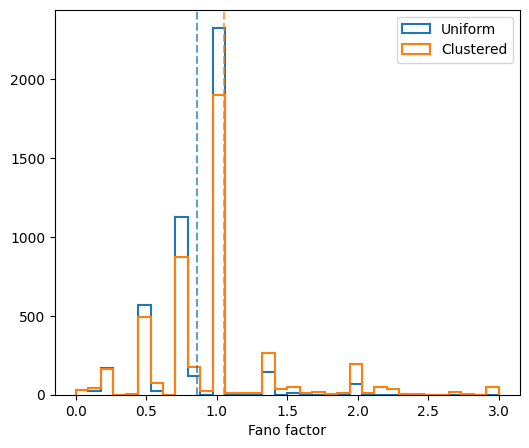

In [34]:
plot_fano_factor(e)
plt.show()

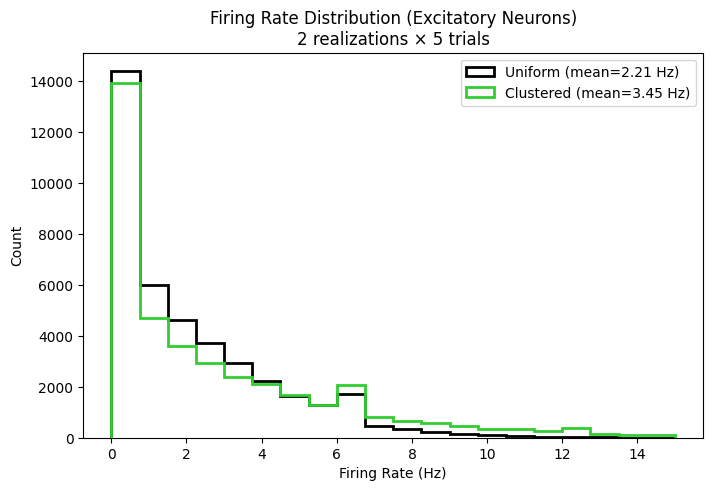

In [38]:
plot_firing_rate_distribution(e)
plt.show()

WARNING    /tmp/ipykernel_300939/3575122413.py:194: RuntimeWarning: invalid value encountered in scalar divide
  coeffs.append(cov_matrix[i][j] / np.sqrt(neuron_vars[i] * neuron_vars[j]))
 [py.warnings]
WARNING    /tmp/ipykernel_300939/3575122413.py:206: RuntimeWarning: invalid value encountered in scalar divide
  coeffs.append(cov_matrix[i][j] / np.sqrt(neuron_vars[i] * neuron_vars[j]))
 [py.warnings]


Mean correlation (all pairs) - Uniform: 0.0004, Clustered: 0.0010
Mean correlation (same cluster) - Uniform: 0.0004, Clustered: 0.2618


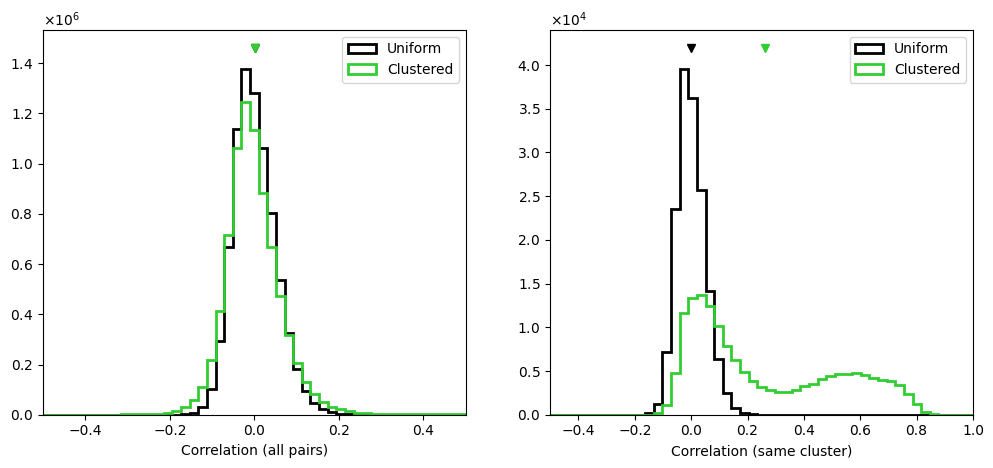

In [36]:
plot_correlation_coefficients(e)
plt.show()

In [ ]:
def run_fano_vs_window(window_times_ms, realizations=1, trials=9, duration=3*second, seed=42):
    """Run experiments for different Fano factor window sizes."""
    # Build networks once (reuse across all window sizes)
    params = ModelParams(duration=duration)
    uniform_params = ClusterParams(enabled=True, R_ee=1.0)
    clustered_params = ClusterParams(enabled=True, R_ee=2.3)
    
    uniform_networks = []
    clustered_networks = []
    for r in range(realizations):
        uniform_networks.append(NeuronNetwork(params, uniform_params, seed=seed + 1000 * r))
        clustered_networks.append(NeuronNetwork(params, clustered_params, seed=seed + 1000 * r))
        print(f"Built network pair {r + 1}/{realizations}")
    
    # Run all trials and store spike data
    print("Running simulations...")
    all_uniform_spikes = []  # List of (spike_times, spike_ids) per realization per trial
    all_clustered_spikes = []
    
    for r in range(realizations):
        uniform_spikes = []
        clustered_spikes = []
        for t in range(trials):
            # Run uniform network
            uniform_networks[r].run()
            uniform_spikes.append((
                np.array(uniform_networks[r].spike_monitor_e.t),
                np.array(uniform_networks[r].spike_monitor_e.i)
            ))
            
            # Run clustered network
            clustered_networks[r].run()
            clustered_spikes.append((
                np.array(clustered_networks[r].spike_monitor_e.t),
                np.array(clustered_networks[r].spike_monitor_e.i)
            ))
            
            print(f"  Realization {r + 1}/{realizations}, Trial {t + 1}/{trials}")
        
        all_uniform_spikes.append(uniform_spikes)
        all_clustered_spikes.append(clustered_spikes)
    
    # Compute Fano factors for each window size
    print("Computing Fano factors for different window sizes...")
    uniform_ffs = []
    clustered_ffs = []
    
    start_t = float(params.analysis_start_t)
    n_e = params.N_E
    
    for window_ms in window_times_ms:
        window_t = window_ms / 1000.0  # Convert ms to seconds
        end_t = start_t + window_t
        
        # Collect spike counts: (realizations, trials, N_E)
        uniform_counts = np.zeros((realizations, trials, n_e), dtype=np.int32)
        clustered_counts = np.zeros((realizations, trials, n_e), dtype=np.int32)
        
        for r in range(realizations):
            for t in range(trials):
                # Uniform
                times, ids = all_uniform_spikes[r][t]
                mask = (times >= start_t) & (times < end_t)
                uniform_counts[r, t, :] = np.bincount(ids[mask], minlength=n_e)
                
                # Clustered
                times, ids = all_clustered_spikes[r][t]
                mask = (times >= start_t) & (times < end_t)
                clustered_counts[r, t, :] = np.bincount(ids[mask], minlength=n_e)
        
        # Compute Fano factor: variance/mean across trials
        uniform_mean = uniform_counts.mean(axis=1)
        uniform_var = uniform_counts.var(axis=1, ddof=1)
        clustered_mean = clustered_counts.mean(axis=1)
        clustered_var = clustered_counts.var(axis=1, ddof=1)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            uniform_ff = np.where(uniform_mean > 0, uniform_var / uniform_mean, np.nan)
            clustered_ff = np.where(clustered_mean > 0, clustered_var / clustered_mean, np.nan)
        
        uniform_ffs.append(np.nanmean(uniform_ff))
        clustered_ffs.append(np.nanmean(clustered_ff))
        
        print(f"  Window {window_ms}ms: Uniform FF={uniform_ffs[-1]:.3f}, Clustered FF={clustered_ffs[-1]:.3f}")
    
    return np.array(window_times_ms), np.array(uniform_ffs), np.array(clustered_ffs)


# Run the analysis
window_times = [25, 50, 75, 100, 125, 150, 175, 200]
windows, uniform_ff, clustered_ff = run_fano_vs_window(
    window_times, 
    realizations=1, 
    trials=9, 
    duration=3*second
)

Built network pair 1/1
Running simulations...
  Realization 1/1, Trial 1/9
  Realization 1/1, Trial 2/9
  Realization 1/1, Trial 3/9
  Realization 1/1, Trial 4/9
  Realization 1/1, Trial 5/9
  Realization 1/1, Trial 6/9
  Realization 1/1, Trial 7/9
  Realization 1/1, Trial 8/9
  Realization 1/1, Trial 9/9
Computing Fano factors for different window sizes...
  Window 25ms: Uniform FF=0.945, Clustered FF=0.939
  Window 50ms: Uniform FF=0.889, Clustered FF=0.974
  Window 75ms: Uniform FF=0.855, Clustered FF=1.038
  Window 100ms: Uniform FF=0.840, Clustered FF=1.090
  Window 125ms: Uniform FF=0.829, Clustered FF=1.147
  Window 150ms: Uniform FF=0.816, Clustered FF=1.181
  Window 175ms: Uniform FF=0.811, Clustered FF=1.256
  Window 200ms: Uniform FF=0.808, Clustered FF=1.320


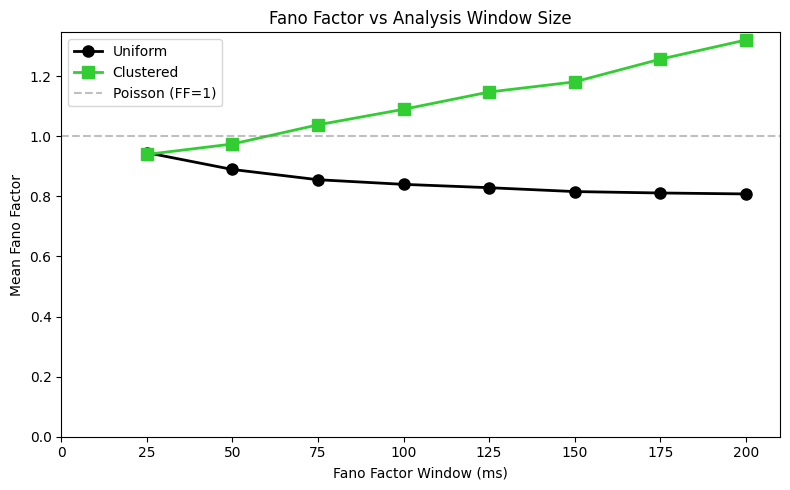

In [22]:
# Plot Fano factor vs window size
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(windows, uniform_ff, 'o-', color='black', linewidth=2, markersize=8, label='Uniform')
ax.plot(windows, clustered_ff, 's-', color='limegreen', linewidth=2, markersize=8, label='Clustered')

ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Poisson (FF=1)')

ax.set_xlabel('Fano Factor Window (ms)')
ax.set_ylabel('Mean Fano Factor')
ax.set_title('Fano Factor vs Analysis Window Size')
ax.legend()
ax.set_xlim(0, 210)
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

## Stimulus Experiment

In [ ]:
def plot_stim_raster(stim):
    fig, (ax_r, ax_s) = plt.subplots(
            2, 1, sharex=True, figsize=(10, 6),
            gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05}
        )
    
    ax_r.tick_params(labelbottom=False)
    intervals = [stim] if isinstance(stim, tuple) else stim
    for t0, t1 in intervals:
        ax_s.axvspan(t0/ms, t1/ms, color="k", alpha=1)
    ax_s.set_ylabel("Stim")
    ax_s.set_yticks([])
    ax_s.set_xlabel("Time (ms)")
    return (ax_r, ax_s)

In [25]:
N_E = 4000
multipliers_2 = np.full((60), 2)
multipliers_1 = np.ones((N_E-60))
multipliers = np.hstack((multipliers_2, multipliers_1))
stimulus_time = (1.5*second,2.5*second)
params = ModelParams(stimulus_multipliers=multipliers, stimulus_time=stimulus_time)


In [26]:
cluster_params = ClusterParams(enabled=True, R_ee=2.3)
clustered_network = NeuronNetwork(params, cluster_params)
clustered_network.run()

In [27]:
cluster_params = ClusterParams(enabled=False, R_ee=1.0)
unclustered_network = NeuronNetwork(params, cluster_params)
unclustered_network.run()

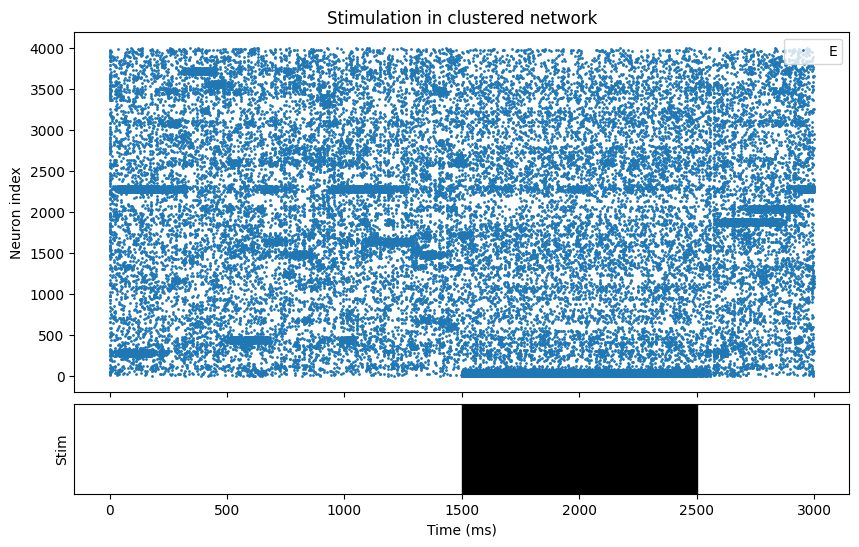

In [29]:
axes = plot_stim_raster(stimulus_time)
plot_spike_raster(
    clustered_network.spike_monitor_e,
    n_e=params.N_E,
    title="Stimulation in clustered network",
    ax=axes[0]
)
plt.show()

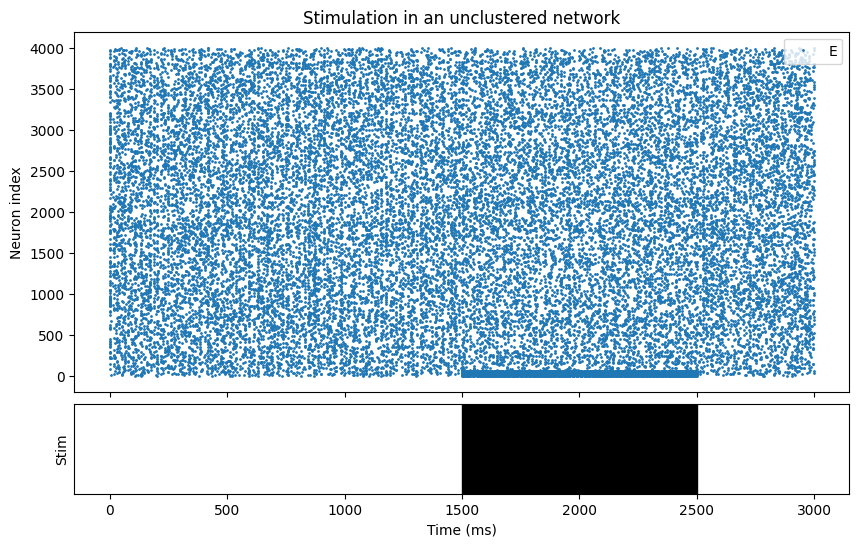

In [30]:
axes = plot_stim_raster(stimulus_time)
plot_spike_raster(
    unclustered_network.spike_monitor_e,
    n_e=params.N_E,
    title="Stimulation in an unclustered network",
    ax=axes[0]
)
plt.show()

# Comparing Fano Factor 